### Problem Statement: Develop a machine learning model to perform sentiment analysis on a collection of text data. The goal is to classify each text entry (e.g., movie review) as positive, negative, or neutral based on its sentiment.

### Import Libraries:

In [ ]:
pip install textblob

In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import string

# Download necessary NLTK data files
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Priya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Load and Prepare the Dataset:

In [4]:
# Load the dataset
df = pd.read_excel('IMDB Dataset.xlsx')

# Display the first few rows of the dataset
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Text Preprocessing:

In [5]:
# Function to clean text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Rejoin tokens into a single string
    cleaned_text = ' '.join(tokens)
    return cleaned_text

# Apply the clean_text function to the review column
df['cleaned_review'] = df['review'].apply(clean_text)

# Display the first few rows of the cleaned data
df.head()


,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


### Sentiment Analysis:

In [6]:
# Function to get sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    # Get sentiment polarity
    sentiment = analysis.sentiment.polarity
    # Determine if sentiment is positive, negative, or neutral
    if sentiment > 0:
        return 'positive'
    elif sentiment < 0:
        return 'negative'
    else:
        return 'neutral'

# Apply the get_sentiment function to the cleaned_review column
df['sentiment'] = df['cleaned_review'].apply(get_sentiment)

# Display the first few rows of the dataset with sentiment
df.head()


,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,positive,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


### Analyze Results:

sentiment
positive    36641
negative    13314
neutral        45
Name: count, dtype: int64


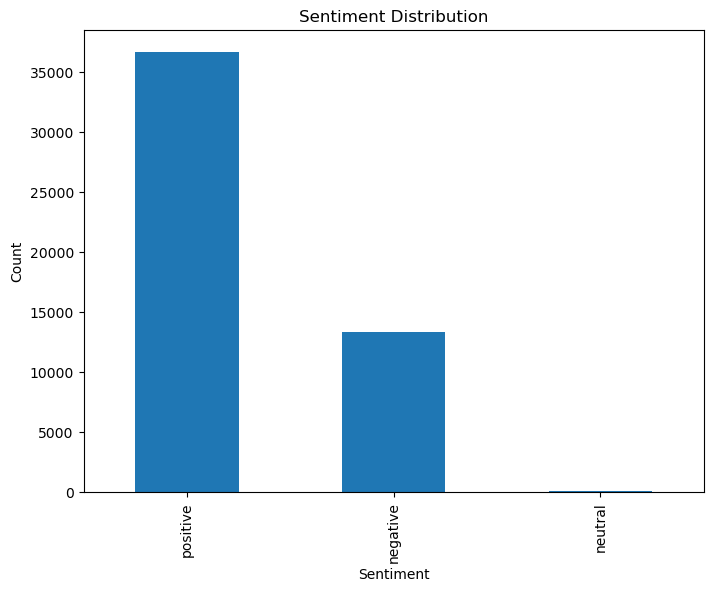

In [7]:
# Display sentiment distribution
sentiment_distribution = df['sentiment'].value_counts()
print(sentiment_distribution)

# Plot sentiment distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sentiment_distribution.plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


### Evaluate Sentiment Analysis:

In [8]:
# Display the first few rows with actual sentiment and predicted sentiment
df['actual_sentiment'] = df['sentiment'].apply(lambda x: 'positive' if x == 'positive' else 'negative')
df[['review', 'cleaned_review', 'sentiment', 'actual_sentiment']].head()

# Calculate accuracy
correct_predictions = df[df['sentiment'] == df['actual_sentiment']].shape[0]
total_predictions = df.shape[0]
accuracy = correct_predictions / total_predictions
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 1.00
